## Reasoning Patch

In [1]:
%load_ext autoreload
%autoreload 2

### Overview

Compares the geometry (norm, cosine similarity, scalar projection) of an arithmetic intervention-effect direction against a reasoning steering direction, layer by layer, to check how closely they align.

### Set-up

In [ ]:
import torch
from tensordict import TensorDict
import gc
import pandas as pd
from tqdm import tqdm

import sys
import os

def find_project_root(start_dir=None):
    path = os.path.abspath(start_dir or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(path, "src")) and os.path.isdir(os.path.join(path, "data")):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("Could not find project root containing src/ and data/.")
        path = parent


project_root = find_project_root()
if project_root not in sys.path:
    sys.path.append(project_root)
if os.path.join(project_root, "src") not in sys.path:
    sys.path.append(os.path.join(project_root, "src"))

import _config
import _mapping
import _prompt
from _intervention import prepare_batch_multitoken_intervention, batch_intervene, forward_with_cache, prepare_batch_multitoken_steering

In [5]:
device = "cuda"
device = "cpu"

### Load Steering Vectors

In [9]:
from pathlib import Path

tensor_dir = Path(project_root) / "experiments/steering/output/GPT-OSS_stepwise/intervention_effect_tensors/h_pre_penultimate_sum"
intervention_effect = torch.load(tensor_dir / "intervention_effect.pt", weights_only=False, map_location=torch.device(device))
mean_intervened_activation = torch.load(tensor_dir / "mean_intervened_activation.pt", weights_only=False, map_location=torch.device(device))
mean_natural_activation = torch.load(tensor_dir / "mean_natural_activation.pt", weights_only=False, map_location=torch.device(device))
confidence = torch.load(Path(project_root) / "experiments/steering/steering_vectors_gpt-oss-20b.pt", map_location=torch.device(device))["backtracking"]["mean"].to(device)

### Vector Norms by Layer

Compares the vectors' magnitudes across layers.

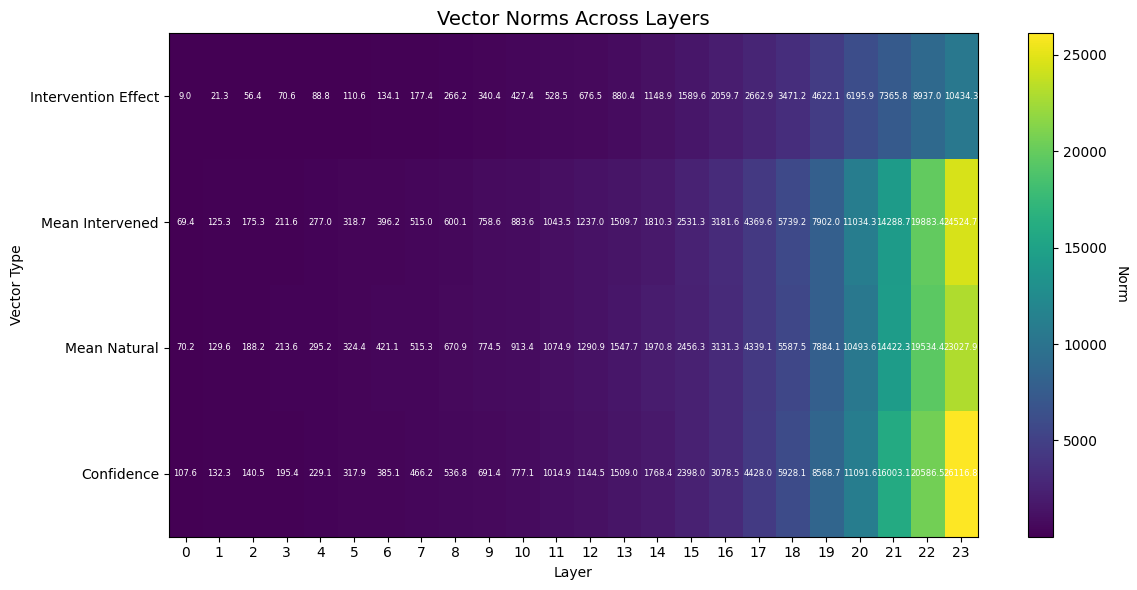

In [10]:
# Plot norms across layers
import matplotlib.pyplot as plt
import numpy as np

# Calculate norms for each vector type across all layers
layers = list(range(24))
ie_norms = []
mia_norms = []
mna_norms = []
conf_norms = []

for layer in layers:
    ie_norms.append(torch.norm(intervention_effect[str(layer)]).cpu().item())
    mia_norms.append(torch.norm(mean_intervened_activation[str(layer)]).cpu().item())
    mna_norms.append(torch.norm(mean_natural_activation[str(layer)]).cpu().item())
    conf_norms.append(torch.norm(confidence[layer]).cpu().item())

# Create heatmap data
norm_data = np.array([ie_norms, mia_norms, mna_norms, conf_norms])

# Create the heatmap
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
im = ax.imshow(norm_data, cmap='viridis', aspect='auto')

# Set labels and title
ax.set_title('Vector Norms Across Layers', fontsize=14)
ax.set_xlabel('Layer')
ax.set_ylabel('Vector Type')
ax.set_xticks(range(24))
ax.set_xticklabels(layers)
ax.set_yticks(range(4))
ax.set_yticklabels(['Intervention Effect', 'Mean Intervened', 'Mean Natural', 'Confidence'])

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Norm', rotation=270, labelpad=15)

# Add text annotations for better readability
for i in range(4):
    for j in range(24):
        text = ax.text(j, i, f'{norm_data[i, j]:.1f}',
                      ha="center", va="center", color="white", fontsize=6)

plt.tight_layout()
plt.show()

### Cosine Similarity Heatmaps

Pairwise directional similarity between the vectors, by layer.

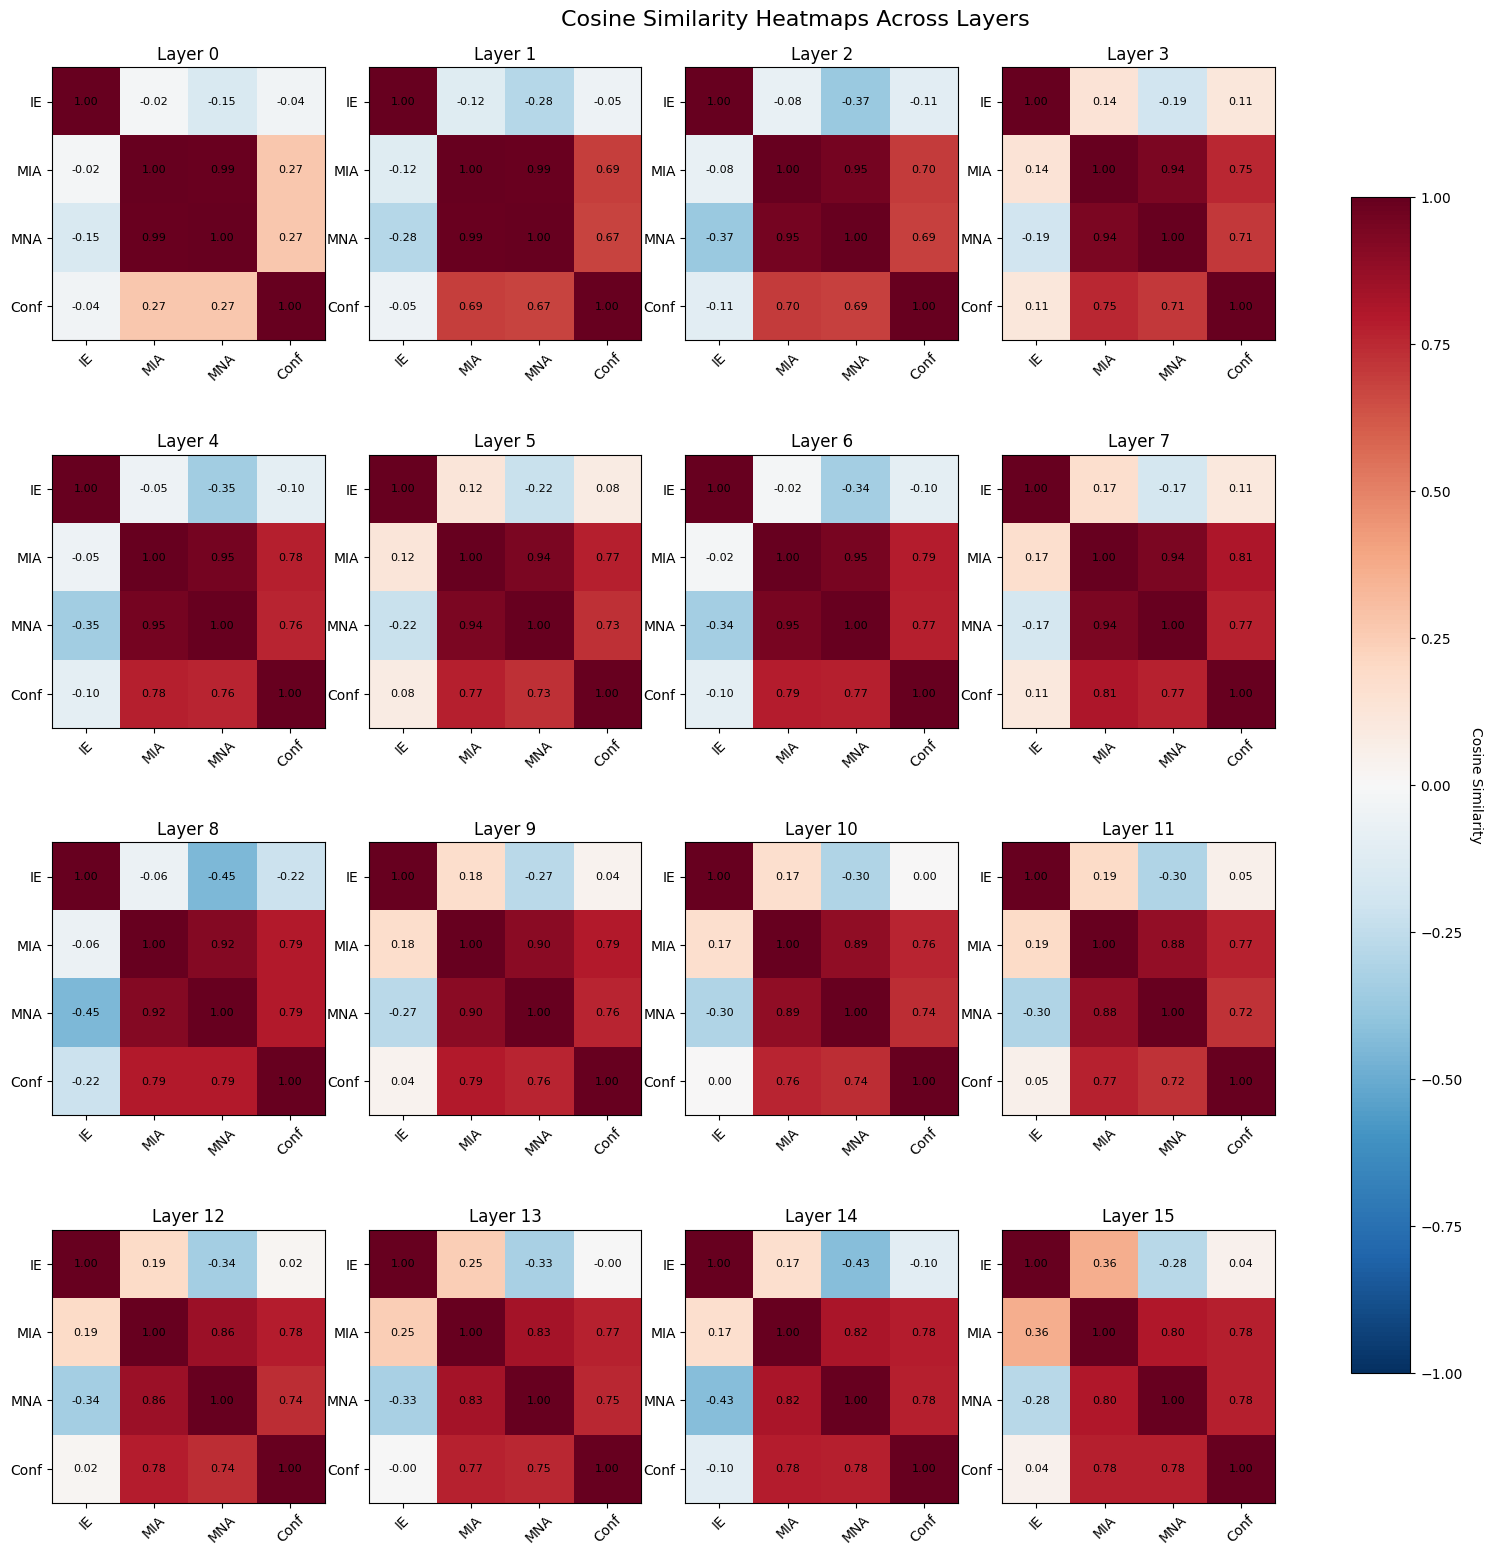

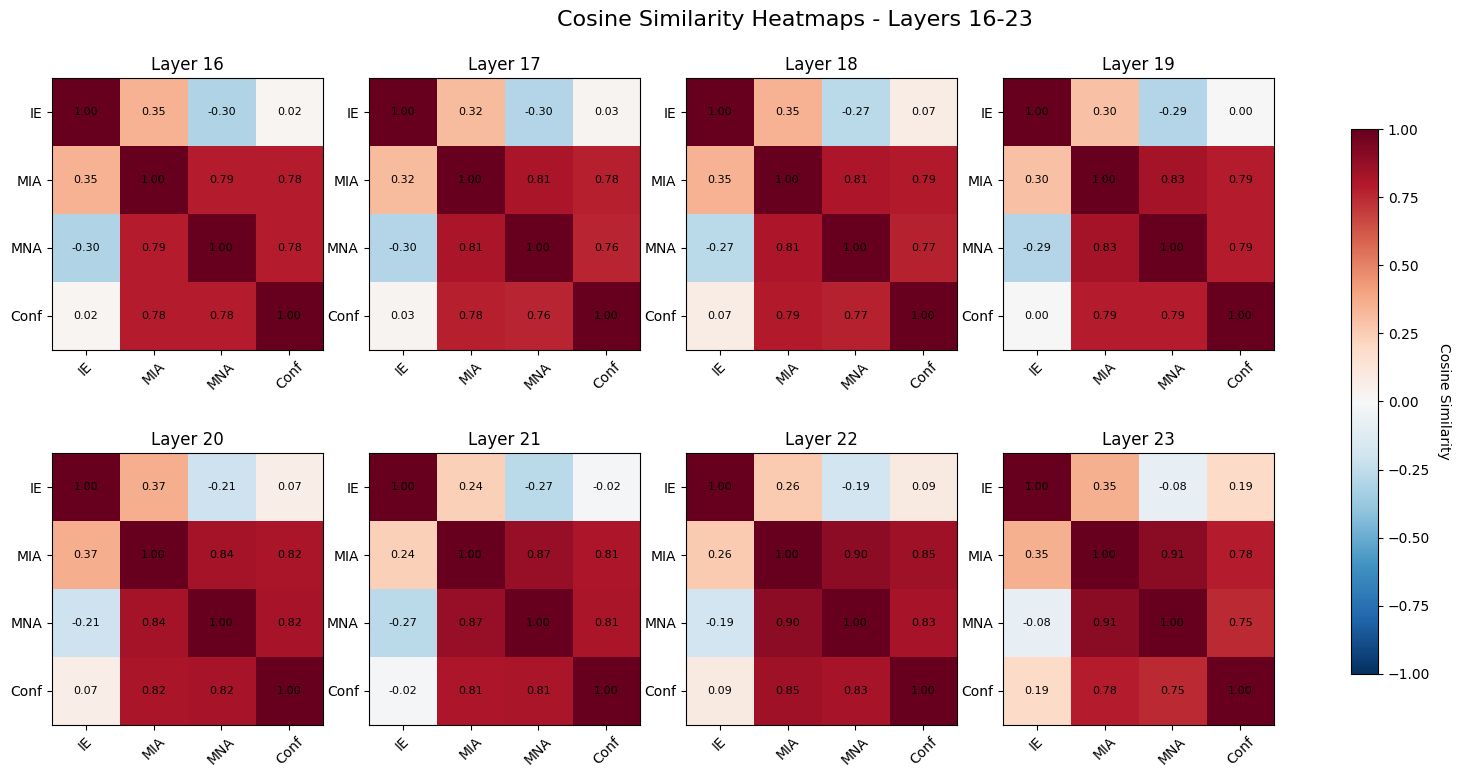

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Cosine Similarity Heatmaps Across Layers', fontsize=16)

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Create heatmaps for each layer
for layer in range(16):  # Only plotting first 16 layers to fit in 4x4 grid
    ax = axes_flat[layer]
    
    # Get vectors for this layer
    ie_vec = intervention_effect[str(layer)]  # intervention effect
    mia_vec = mean_intervened_activation[str(layer)]  # mean intervened activation
    mna_vec = mean_natural_activation[str(layer)]  # mean natural activation
    conf_vec = confidence[layer]  # confidence vector
    
    # Stack vectors for cosine similarity computation
    vectors = torch.stack([ie_vec, mia_vec, mna_vec, conf_vec])
    
    # Compute cosine similarity matrix
    cos_sim_matrix = torch.nn.functional.cosine_similarity(
        vectors.unsqueeze(1), vectors.unsqueeze(0), dim=2
    ).cpu().numpy()
    
    # Create heatmap
    im = ax.imshow(cos_sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'Layer {layer}')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(['IE', 'MIA', 'MNA', 'Conf'], rotation=45)
    ax.set_yticklabels(['IE', 'MIA', 'MNA', 'Conf'])
    
    # Add text annotations
    for i in range(4):
        for j in range(4):
            text = ax.text(j, i, f'{cos_sim_matrix[i, j]:.2f}',
                         ha="center", va="center", color="black", fontsize=8)

# Add colorbar
plt.tight_layout()
cbar = fig.colorbar(im, ax=axes, shrink=0.8, aspect=20)
cbar.set_label('Cosine Similarity', rotation=270, labelpad=15)

plt.show()

# Also create a second plot for layers 16-23
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
fig2.suptitle('Cosine Similarity Heatmaps - Layers 16-23', fontsize=16)
axes2_flat = axes2.flatten()

for i, layer in enumerate(range(16, 24)):
    ax = axes2_flat[i]
    
    # Get vectors for this layer
    ie_vec = intervention_effect[str(layer)]
    mia_vec = mean_intervened_activation[str(layer)]
    mna_vec = mean_natural_activation[str(layer)]
    conf_vec = confidence[layer]
    
    # Stack vectors for cosine similarity computation
    vectors = torch.stack([ie_vec, mia_vec, mna_vec, conf_vec])
    
    # Compute cosine similarity matrix
    cos_sim_matrix = torch.nn.functional.cosine_similarity(
        vectors.unsqueeze(1), vectors.unsqueeze(0), dim=2
    ).cpu().numpy()
    
    # Create heatmap
    im = ax.imshow(cos_sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'Layer {layer}')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(['IE', 'MIA', 'MNA', 'Conf'], rotation=45)
    ax.set_yticklabels(['IE', 'MIA', 'MNA', 'Conf'])
    
    # Add text annotations
    for i in range(4):
        for j in range(4):
            text = ax.text(j, i, f'{cos_sim_matrix[i, j]:.2f}',
                         ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
cbar2 = fig2.colorbar(im, ax=axes2, shrink=0.8, aspect=20)
cbar2.set_label('Cosine Similarity', rotation=270, labelpad=15)

plt.show()

### Scalar Projection Heatmaps

Pairwise scalar projections between the vectors, by layer.

In [12]:
def get_scalar_projection(vector_1, vector_2):
    return torch.dot(vector_1, vector_2) / (torch.norm(vector_2)**2)

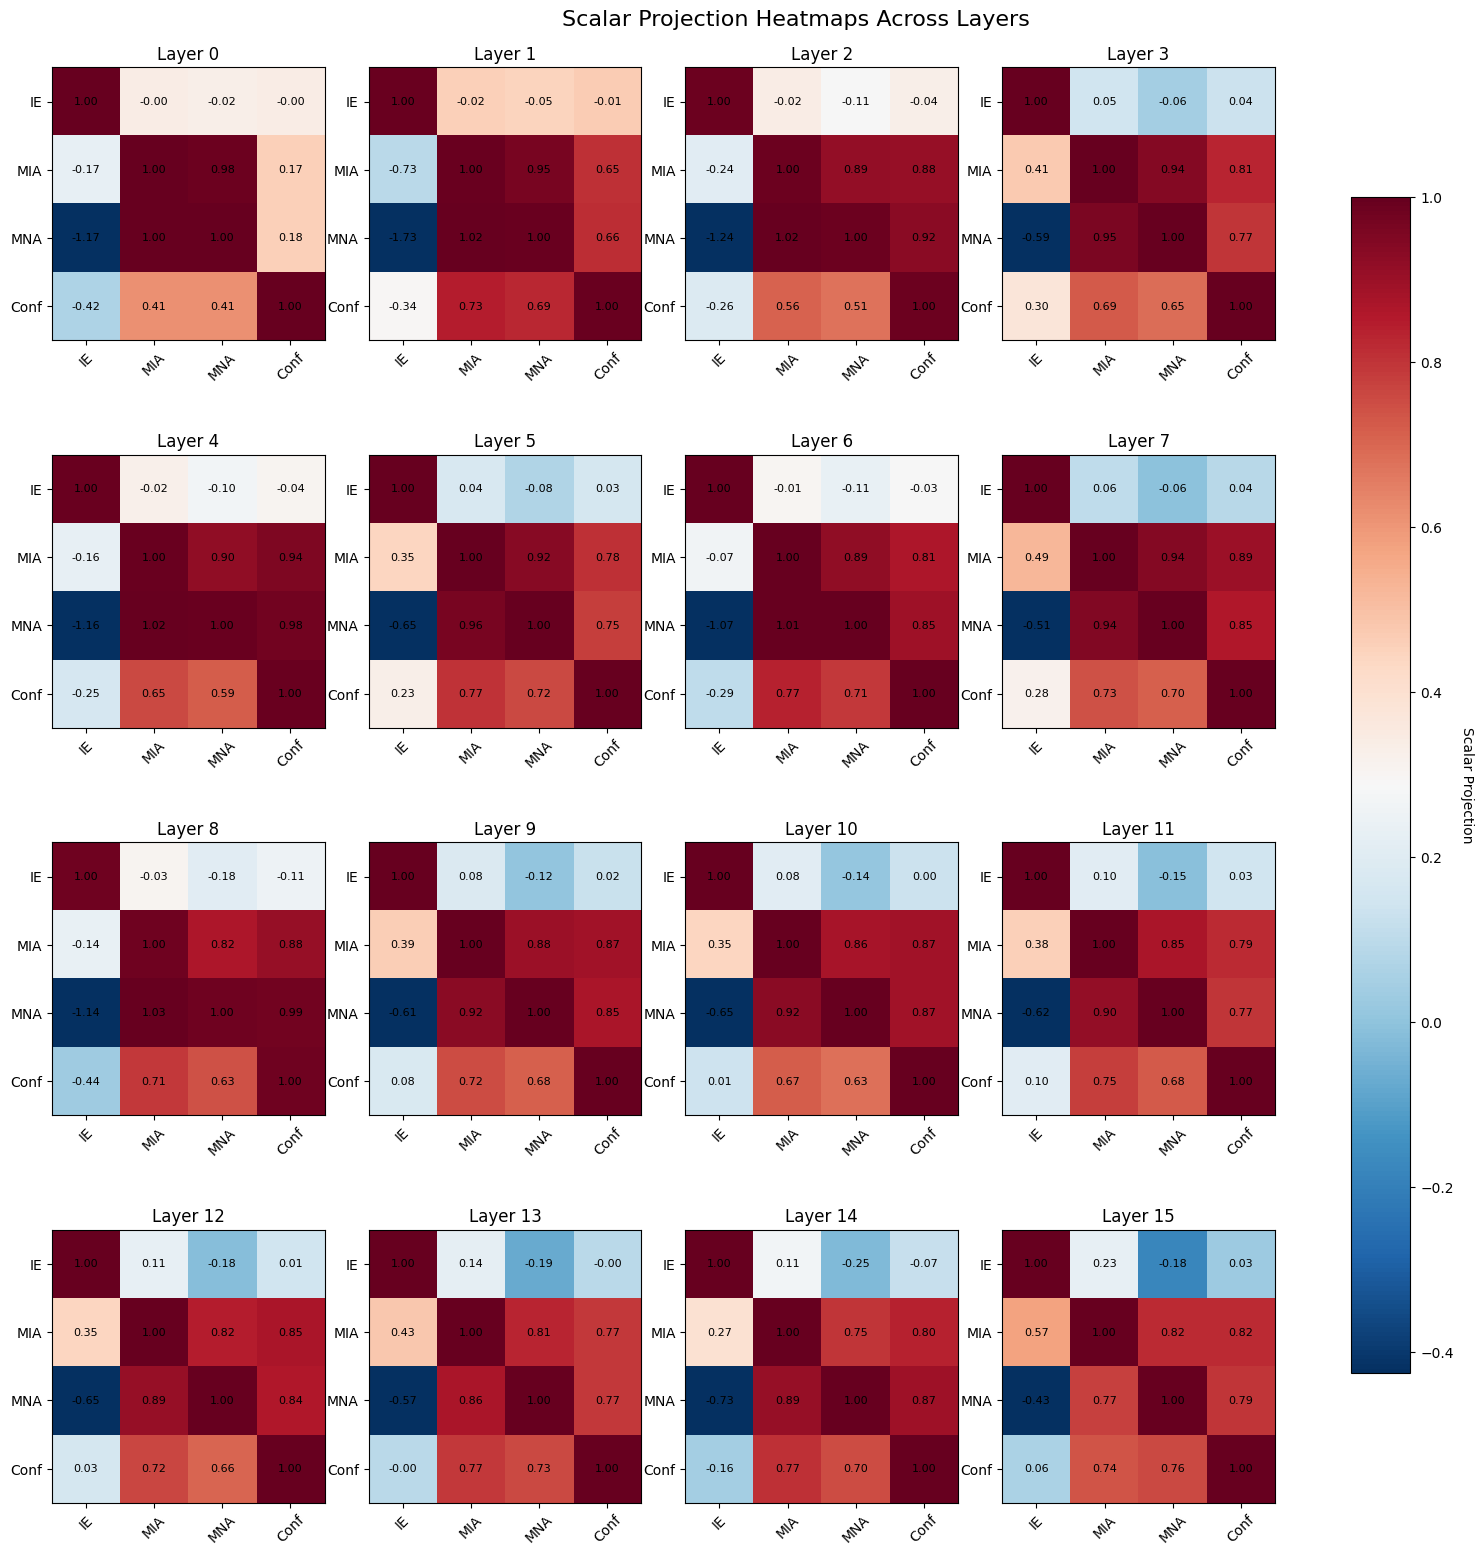

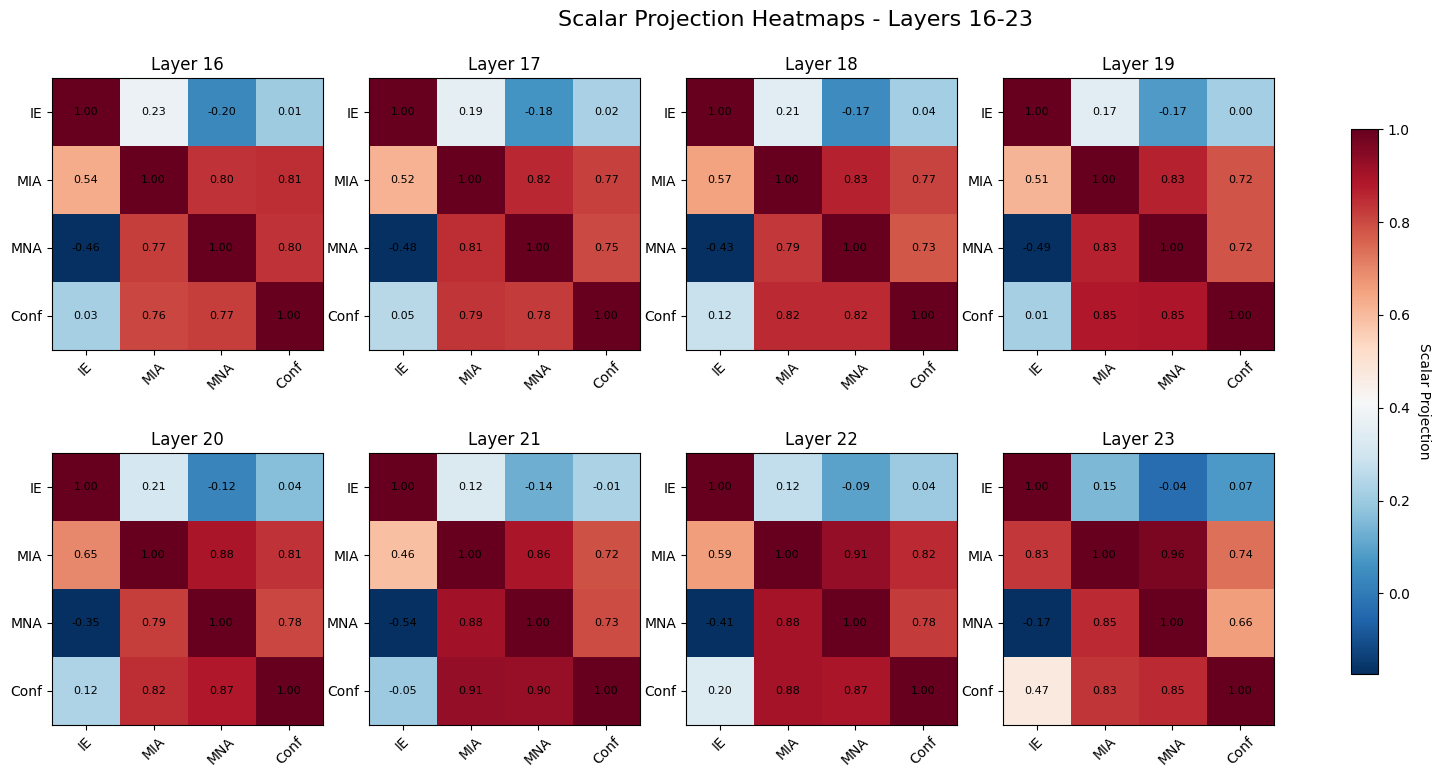

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Scalar Projection Heatmaps Across Layers', fontsize=16)

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Create heatmaps for each layer
for layer in range(16):  # Only plotting first 16 layers to fit in 4x4 grid
    ax = axes_flat[layer]
    
    # Get vectors for this layer
    ie_vec = intervention_effect[str(layer)]  # intervention effect
    mia_vec = mean_intervened_activation[str(layer)]  # mean intervened activation
    mna_vec = mean_natural_activation[str(layer)]  # mean natural activation
    conf_vec = confidence[layer]  # confidence vector
    
    # Stack vectors for scalar projection computation
    vectors = torch.stack([ie_vec, mia_vec, mna_vec, conf_vec])
    
    # Compute scalar projection matrix
    scalar_proj_matrix = torch.zeros(4, 4)
    for i in range(4):
        for j in range(4):
            if i != j:  # Don't compute projection of vector onto itself
                scalar_proj_matrix[i, j] = get_scalar_projection(vectors[i], vectors[j])
            else:
                scalar_proj_matrix[i, j] = 1 # torch.norm(vectors[i])  # Length of vector when projected onto itself
    
    scalar_proj_matrix = scalar_proj_matrix.cpu().numpy()
    
    # Create heatmap
    im = ax.imshow(scalar_proj_matrix, cmap='RdBu_r', vmin=scalar_proj_matrix.min(), vmax=scalar_proj_matrix.max())
    ax.set_title(f'Layer {layer}')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(['IE', 'MIA', 'MNA', 'Conf'], rotation=45)
    ax.set_yticklabels(['IE', 'MIA', 'MNA', 'Conf'])
    
    # Add text annotations
    for i in range(4):
        for j in range(4):
            text = ax.text(j, i, f'{scalar_proj_matrix[i, j]:.2f}',
                         ha="center", va="center", color="black", fontsize=8)

# Add colorbar
plt.tight_layout()
cbar = fig.colorbar(im, ax=axes, shrink=0.8, aspect=20)
cbar.set_label('Scalar Projection', rotation=270, labelpad=15)

plt.show()

# Also create a second plot for layers 16-23
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
fig2.suptitle('Scalar Projection Heatmaps - Layers 16-23', fontsize=16)
axes2_flat = axes2.flatten()

for i, layer in enumerate(range(16, 24)):
    ax = axes2_flat[i]
    
    # Get vectors for this layer
    ie_vec = intervention_effect[str(layer)]
    mia_vec = mean_intervened_activation[str(layer)]
    mna_vec = mean_natural_activation[str(layer)]
    conf_vec = confidence[layer]
    
    # Stack vectors for scalar projection computation
    vectors = torch.stack([ie_vec, mia_vec, mna_vec, conf_vec])
    
    # Compute scalar projection matrix
    scalar_proj_matrix = torch.zeros(4, 4)
    for i in range(4):
        for j in range(4):
            if i != j:  # Don't compute projection of vector onto itself
                scalar_proj_matrix[i, j] = get_scalar_projection(vectors[i], vectors[j])
            else:
                scalar_proj_matrix[i, j] = 1 # torch.norm(vectors[i])  # Length of vector when projected onto itself
    
    scalar_proj_matrix = scalar_proj_matrix.cpu().numpy()
    
    # Create heatmap
    im = ax.imshow(scalar_proj_matrix, cmap='RdBu_r', vmin=scalar_proj_matrix.min(), vmax=scalar_proj_matrix.max())
    ax.set_title(f'Layer {layer}')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(['IE', 'MIA', 'MNA', 'Conf'], rotation=45)
    ax.set_yticklabels(['IE', 'MIA', 'MNA', 'Conf'])
    
    # Add text annotations
    for i in range(4):
        for j in range(4):
            text = ax.text(j, i, f'{scalar_proj_matrix[i, j]:.2f}',
                         ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
cbar2 = fig2.colorbar(im, ax=axes2, shrink=0.8, aspect=20)
cbar2.set_label('Scalar Projection', rotation=270, labelpad=15)

plt.show()

### Per-Example Diff Recomputation

Recomputes the activation-patch effect per example, rather than as an aggregated mean, to compare against the reference steering directions below.

In [ ]:
prompt_config = _config.PromptConfig(
    model_type="GPT-OSS_stepwise", # GPT-OSS or R1
    prompt_type="h_pre_penultimate_sum", # {null / h / h1 / h2}_{null / pre_result / pre_final_sum / ...}
)
intervention_config = _config.InterventionConfig(
    intervention_loc="", # restatement or reasoning or restatement_and_reasoning
    intervention_ids=[20],
    tok_pos_fn=_mapping.intervene_id_to_tok_pos_stepwise_3_digit_h,
)
result_dir = "intervention_effect_tensors"

# Steering Config———————————————————————————————————————
batch_size = 24
device = "cuda:7"

In [ ]:
num_layers = 24
hidden_size = 2880
model, tokenizer = _config.load_model(prompt_config.model_type)
if "GPT-OSS" in prompt_config.model_type:
    num_layers = model.config.num_hidden_layers
    hidden_size = model.config.hidden_size

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [7]:
prompts = _config.load_prompts(prompt_config)
print(f"loaded {len(prompts)} prompts")

loaded 256 prompts


In [8]:
intervention_ids = _config.resolve_intervention_ids(
    prompt_config.model_type,
    prompt_config.prompt_type,
    intervention_config.intervention_loc,
    intervention_config.intervention_ids,
)
print(intervention_ids)

[20]


In [9]:
tok_pos_list = _config.build_tok_pos_list(intervention_config.tok_pos_fn, intervention_ids)
print(tok_pos_list)

[235]


Reference directions used for comparison below.

In [ ]:
activation_layer = 16
device = "cuda:4"

steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
steering_vector = steering_vectors["backtracking"]["mean"][activation_layer].to(device).to(torch.bfloat16)
mean_diff_vector = torch.load("experiments/activation_intervention/intervention_effect_gpt-oss-20b.pt").to(device).to(torch.bfloat16)

def get_scalar_projection(vector_1, vector_2):
    return torch.dot(vector_1, vector_2) / torch.norm(vector_2)

In [ ]:
backtrack_cosine_similarities = []
backtrack_scalar_projection_ratios = []
mean_diff_cosine_similarities = []
mean_diff_scalar_projection_ratios = []
for i in tqdm(range(0, len(prompts), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = prompts.iloc[i:i+batch_size]

    tokens = tokenizer(batch_rows['base_prompt'].tolist(), add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, cache = forward_with_cache(model, tokens["input_ids"], attention_mask=tokens["attention_mask"])
    activations = cache[f"model.layers.{activation_layer}"][:,tok_pos_list,:]
    
    intervention_prompts = [_prompt.get_intervened_prompt(intervention_ids, row['base_prompt'], row['source_prompt']) for _, row in batch_rows.iterrows()]
    intervened_tokens = tokenizer(intervention_prompts, add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, intervened_cache = forward_with_cache(model, intervened_tokens["input_ids"], attention_mask=intervened_tokens["attention_mask"])
    intervened_activations = intervened_cache[f"model.layers.{activation_layer}"][:,tok_pos_list,:]

    for intervened_activation, activation in zip(intervened_activations, activations):
        diff = intervened_activation[0] - activation[0]
        backtrack_cosine_similarities.append(torch.nn.functional.cosine_similarity(diff, steering_vector, dim=0))
        backtrack_scalar_projection_ratios.append(get_scalar_projection(diff, steering_vector) / torch.norm(steering_vector))
        mean_diff_cosine_similarities.append(torch.nn.functional.cosine_similarity(diff, mean_diff_vector, dim=0))
        mean_diff_scalar_projection_ratios.append(get_scalar_projection(diff, mean_diff_vector) / torch.norm(mean_diff_vector))

    del tokens, intervened_tokens, cache, intervened_cache
    torch.cuda.empty_cache()
    gc.collect()
   


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [01:53<00:00, 10.29s/it]


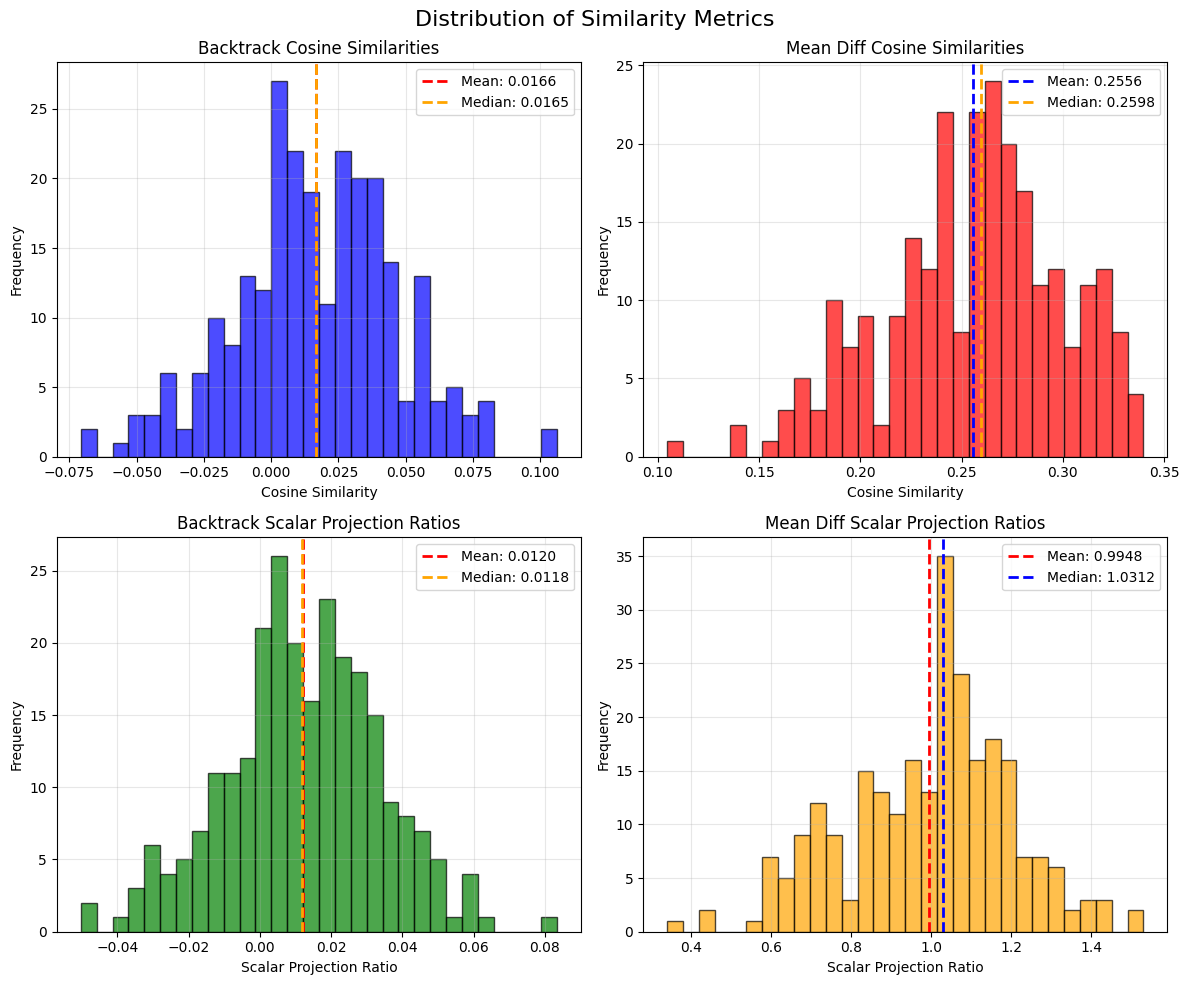

Summary Statistics:
Backtrack Cosine Similarities - Mean: 0.0166, Median: 0.0165, Std: 0.0302
Mean Diff Cosine Similarities - Mean: 0.2556, Median: 0.2598, Std: 0.0440
Backtrack Scalar Projection Ratios - Mean: 0.0120, Median: 0.0118, Std: 0.0217
Mean Diff Scalar Projection Ratios - Mean: 0.9948, Median: 1.0312, Std: 0.2082


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Convert tensors to numpy arrays for plotting
backtrack_cosine_similarities_np = [sim.cpu().to(torch.float32).numpy() for sim in backtrack_cosine_similarities]
mean_diff_cosine_similarities_np = [sim.cpu().to(torch.float32).numpy() for sim in mean_diff_cosine_similarities]
backtrack_scalar_projection_ratios_np = [ratio.cpu().to(torch.float32).numpy() for ratio in backtrack_scalar_projection_ratios]
mean_diff_scalar_projection_ratios_np = [ratio.cpu().to(torch.float32).numpy() for ratio in mean_diff_scalar_projection_ratios]

# Calculate statistics
backtrack_cos_mean = np.mean(backtrack_cosine_similarities_np)
backtrack_cos_median = np.median(backtrack_cosine_similarities_np)
mean_diff_cos_mean = np.mean(mean_diff_cosine_similarities_np)
mean_diff_cos_median = np.median(mean_diff_cosine_similarities_np)
backtrack_proj_mean = np.mean(backtrack_scalar_projection_ratios_np)
backtrack_proj_median = np.median(backtrack_scalar_projection_ratios_np)
mean_diff_proj_mean = np.mean(mean_diff_scalar_projection_ratios_np)
mean_diff_proj_median = np.median(mean_diff_scalar_projection_ratios_np)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Similarity Metrics', fontsize=16)

# Plot backtrack cosine similarities
axes[0, 0].hist(backtrack_cosine_similarities_np, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(backtrack_cos_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {backtrack_cos_mean:.4f}')
axes[0, 0].axvline(backtrack_cos_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {backtrack_cos_median:.4f}')
axes[0, 0].set_title('Backtrack Cosine Similarities')
axes[0, 0].set_xlabel('Cosine Similarity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot mean diff cosine similarities
axes[0, 1].hist(mean_diff_cosine_similarities_np, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[0, 1].axvline(mean_diff_cos_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_diff_cos_mean:.4f}')
axes[0, 1].axvline(mean_diff_cos_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {mean_diff_cos_median:.4f}')
axes[0, 1].set_title('Mean Diff Cosine Similarities')
axes[0, 1].set_xlabel('Cosine Similarity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot backtrack scalar projection ratios
axes[1, 0].hist(backtrack_scalar_projection_ratios_np, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].axvline(backtrack_proj_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {backtrack_proj_mean:.4f}')
axes[1, 0].axvline(backtrack_proj_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {backtrack_proj_median:.4f}')
axes[1, 0].set_title('Backtrack Scalar Projection Ratios')
axes[1, 0].set_xlabel('Scalar Projection Ratio')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot mean diff scalar projection ratios
axes[1, 1].hist(mean_diff_scalar_projection_ratios_np, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].axvline(mean_diff_proj_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_diff_proj_mean:.4f}')
axes[1, 1].axvline(mean_diff_proj_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {mean_diff_proj_median:.4f}')
axes[1, 1].set_title('Mean Diff Scalar Projection Ratios')
axes[1, 1].set_xlabel('Scalar Projection Ratio')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(f"Backtrack Cosine Similarities - Mean: {backtrack_cos_mean:.4f}, Median: {backtrack_cos_median:.4f}, Std: {np.std(backtrack_cosine_similarities_np):.4f}")
print(f"Mean Diff Cosine Similarities - Mean: {mean_diff_cos_mean:.4f}, Median: {mean_diff_cos_median:.4f}, Std: {np.std(mean_diff_cosine_similarities_np):.4f}")
print(f"Backtrack Scalar Projection Ratios - Mean: {backtrack_proj_mean:.4f}, Median: {backtrack_proj_median:.4f}, Std: {np.std(backtrack_scalar_projection_ratios_np):.4f}")
print(f"Mean Diff Scalar Projection Ratios - Mean: {mean_diff_proj_mean:.4f}, Median: {mean_diff_proj_median:.4f}, Std: {np.std(mean_diff_scalar_projection_ratios_np):.4f}")
